In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("spotify_top_1000_tracks.csv")

print(df.head())
print(df.columns)

                 track_name          artist  \
0  All The Stars (with SZA)  Kendrick Lamar   
1                   Starboy      The Weeknd   
2                  Señorita    Shawn Mendes   
3                Heat Waves   Glass Animals   
4           Let Me Love You        DJ Snake   

                                               album release_date  popularity  \
0  Black Panther The Album Music From And Inspire...   2018-02-09          95   
1                                            Starboy   2016-11-25          90   
2                                           Señorita   2019-06-21          80   
3                                          Dreamland   2020-08-07          87   
4                                             Encore   2016-08-05          87   

                                         spotify_url                      id  \
0  https://open.spotify.com/track/3GCdLUSnKSMJhs4...  3GCdLUSnKSMJhs4Tj6CV3s   
1  https://open.spotify.com/track/7MXVkk9YMctZqd1...  7MXVkk9YMctZqd1S

                                          track_name                 artist  \
710                                         Lost Boy                  Jaden   
610                                I'm Getting Ready    Tasha Cobbs Leonard   
64                                           Mirrors      Justin Timberlake   
63   What Goes Around.../...Comes Around (Interlude)      Justin Timberlake   
622                               Achilles Come Down         Gang of Youths   
689                             Never Let Go (Of Me)                 Baltra   
682            House Of Balloons / Glass Table Girls             The Weeknd   
549                                             Stan                 Eminem   
671                                        Galvanize  The Chemical Brothers   
37                                       After Hours             The Weeknd   

     duration_min  
710      9.497883  
610      8.436667  
64       8.069100  
63       7.476217  
622      7.035767  
689      6

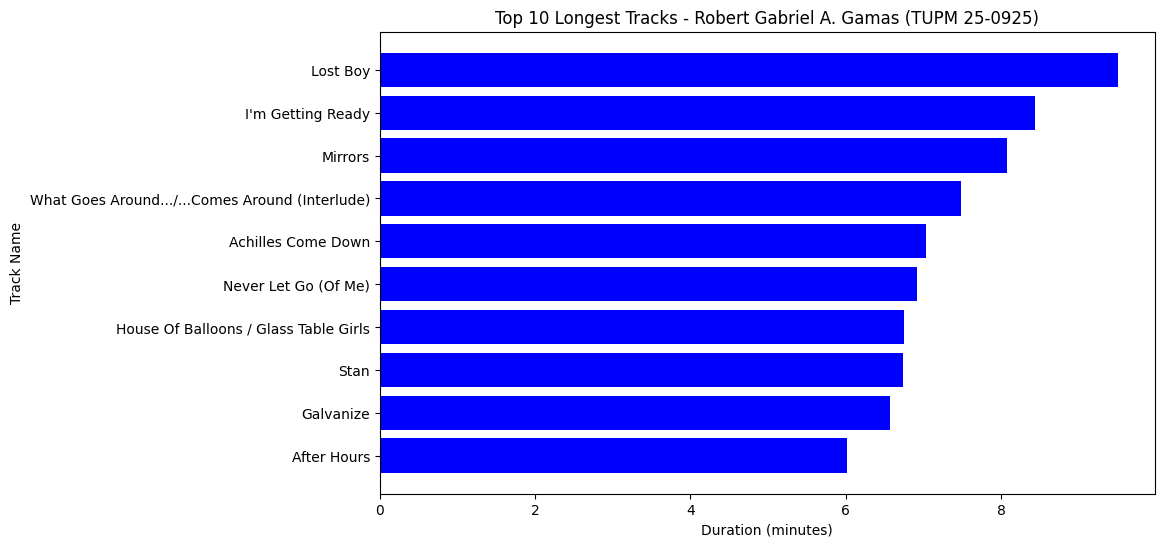

In [4]:
student_name = "Robert Gabriel A. Gamas"
student_id = "TUPM 25-0925"
color_bar = "blue"

# Step 1: Select needed columns
df1 = df[['track_name', 'artist', 'duration_min']].dropna()

# Step 2: Sort by duration (longest first)
df1_sorted = df1.sort_values(by='duration_min', ascending=False)

# Step 3: Get top 10 longest tracks
top10 = df1_sorted.head(10)

# Step 4: Print table
print(top10)

# Step 5: Plot bar chart
plt.figure(figsize=(10,6))

plt.barh(top10['track_name'], top10['duration_min'], color=color_bar)

plt.title(f"Top 10 Longest Tracks - {student_name} ({student_id})")
plt.xlabel("Duration (minutes)")
plt.ylabel("Track Name")

plt.gca().invert_yaxis()
plt.show()

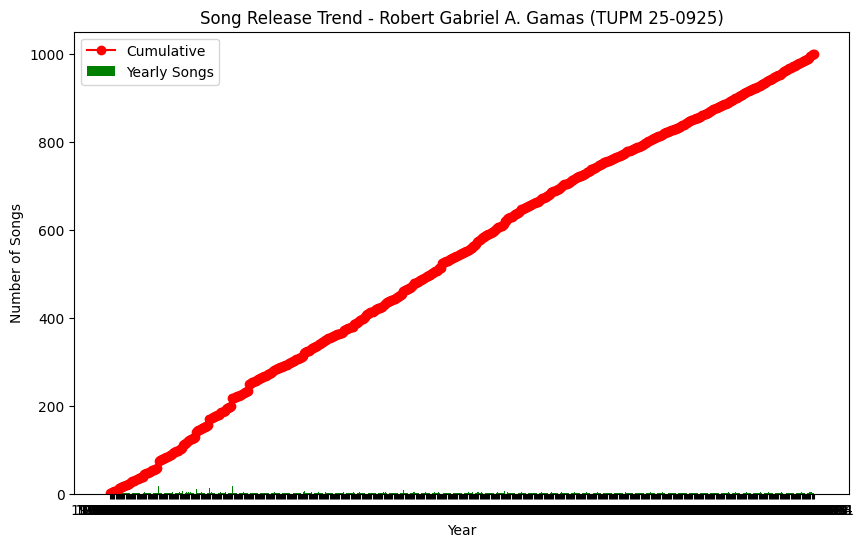

In [11]:
student_name = "Robert Gabriel A. Gamas"
student_id = "TUPM 25-0925"

color_bar = "green"
color_line = "red"

# Step 1: group by year
yearly = df.groupby('release_date').size().reset_index(name='count')

# Step 2: cumulative count
yearly['cumulative'] = yearly['count'].cumsum()

# Step 3: plot
plt.figure(figsize=(10,6))

plt.bar(yearly['release_date'], yearly['count'], color=color_bar, label="Yearly Songs")

plt.plot(yearly['release_date'], yearly['cumulative'], color=color_line, marker='o', label="Cumulative")

plt.title(f"Song Release Trend - {student_name} ({student_id})")
plt.xlabel("Year")
plt.ylabel("Number of Songs")
plt.legend()

plt.show()

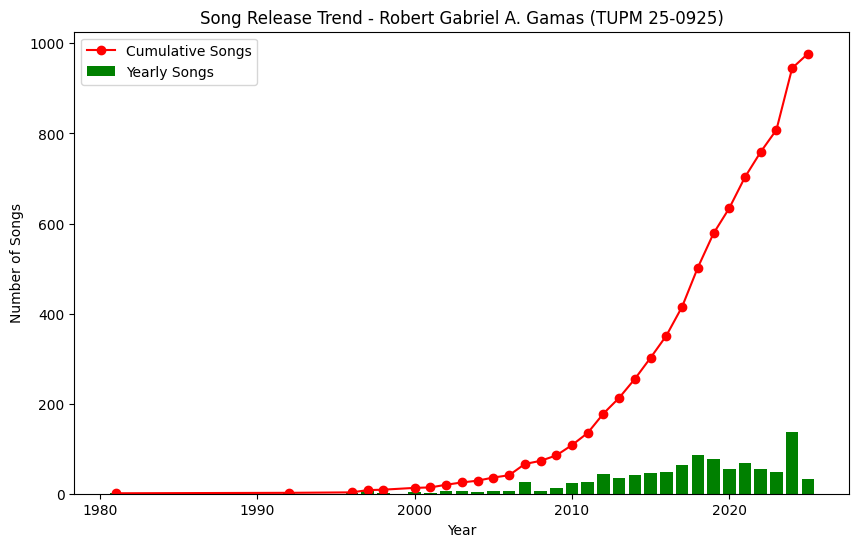

In [25]:
student_name = "Robert Gabriel A. Gamas"
student_id = "TUPM 25-0925"

color_bar = "green"
color_line = "red"

# Step 1: Convert release_date to datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Step 2: Extract year
df['year'] = df['release_date'].dt.year

# Step 3: Group by year
yearly = df.groupby('year').size().reset_index(name='count')

# Step 4: Sort years properly
yearly = yearly.sort_values(by='year')

# Step 5: Cumulative sum
yearly['cumulative'] = yearly['count'].cumsum()

# Step 6: Plot
plt.figure(figsize=(10,6))

plt.bar(
    yearly['year'],
    yearly['count'],
    color=color_bar,
    label="Yearly Songs"
)

plt.plot(
    yearly['year'],
    yearly['cumulative'],
    color=color_line,
    marker='o',
    label="Cumulative Songs"
)

plt.title(f"Song Release Trend - {student_name} ({student_id})")
plt.xlabel("Year")
plt.ylabel("Number of Songs")
plt.legend()

plt.show()

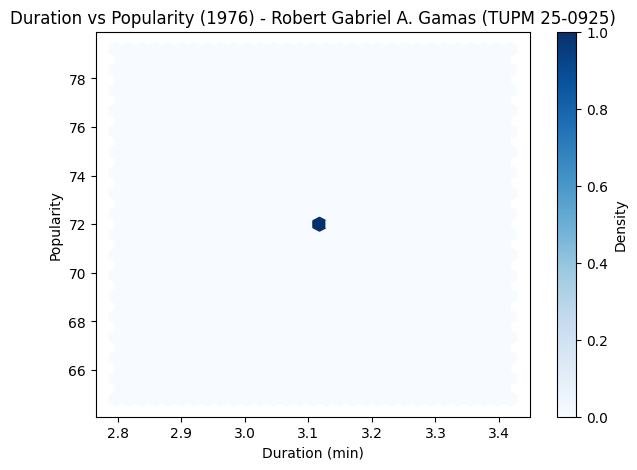

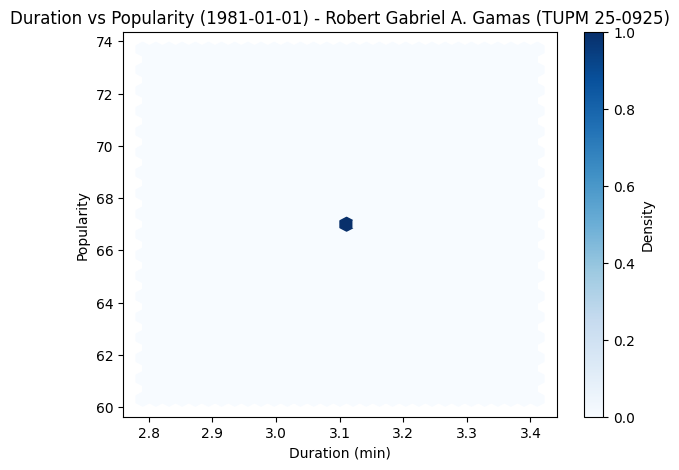

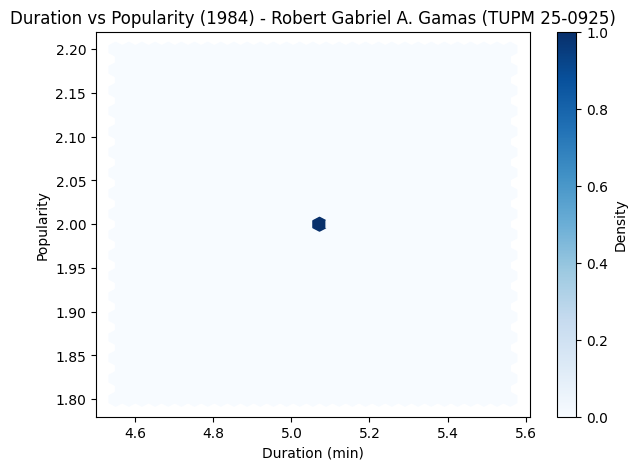

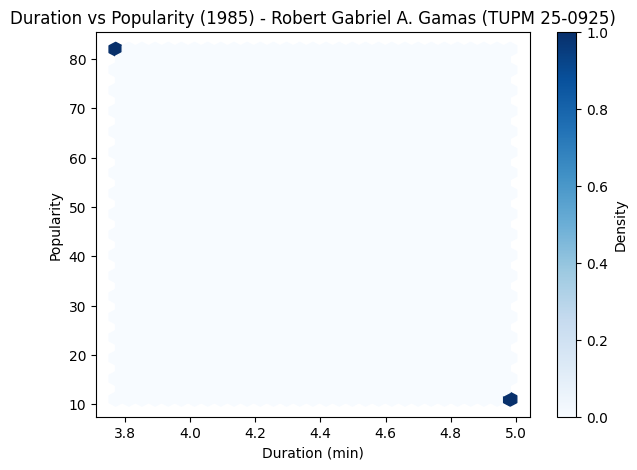

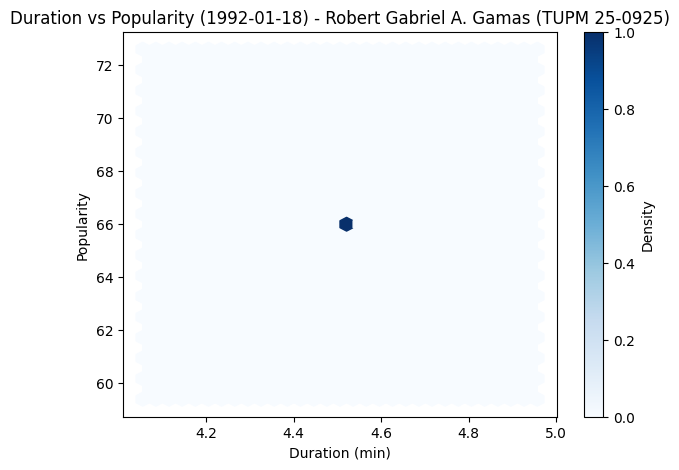

In [23]:
student_name = "Robert Gabriel A. Gamas"
student_id = "TUPM 25-0925"
cmap_color = "Blues"

years = sorted(df['release_date'].dropna().unique())[:5]  # LIMIT TO 5 YEARS

for y in years:
    subset = df[df['release_date'] == y]

    plt.figure(figsize=(7,5))

    plt.hexbin(
        subset['duration_min'],
        subset['popularity'],
        gridsize=30,
        cmap=cmap_color
    )

    plt.title(f"Duration vs Popularity ({y}) - {student_name} ({student_id})")
    plt.xlabel("Duration (min)")
    plt.ylabel("Popularity")

    plt.colorbar(label="Density")

    plt.show()